In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project paths
DATA_PATH = r"../data/raw/ftir_plastic_c4/FTIR-PLASTIC-c4/FTIR_PLASTIC_c4.csv"
RESULTS_DIR = r"../results/classification/eda_spectra"

os.makedirs(RESULTS_DIR, exist_ok=True)

print("Imports and paths ready.")
print("Dataset:", DATA_PATH)
print("Results:", RESULTS_DIR)

Imports and paths ready.
Dataset: ../data/raw/ftir_plastic_c4/FTIR-PLASTIC-c4/FTIR_PLASTIC_c4.csv
Results: ../results/classification/eda_spectra


In [3]:
df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
print("\nPolymer distribution:")
print(df["Polymer"].value_counts().sort_index())

Dataset shape: (3000, 7478)

Polymer distribution:
Polymer
HDPE    500
LDPE    500
PET     500
PP      500
PS      500
PVC     500
Name: count, dtype: int64


In [4]:
x_cols = [c for c in df.columns if c.startswith("Data(x)")]
y_cols = [c for c in df.columns if c.startswith("Data(y)")]
wavenumbers = df[x_cols].iloc[0].to_numpy(dtype=float)
spectra = df[y_cols].to_numpy(dtype=float)
labels = df["Polymer"].to_numpy()
print("Number of spectral points:", len(wavenumbers))
print("Spectra shape:", spectra.shape)
print("Labels shape:", labels.shape)
print("Wavenumber range:", wavenumbers[0], "to", wavenumbers[-1], "cm⁻¹")
print("Missing spectral values:", np.isnan(spectra).sum())

Number of spectral points: 3736
Spectra shape: (3000, 3736)
Labels shape: (3000,)
Wavenumber range: 399.1927 to 4000.6045 cm⁻¹
Missing spectral values: 0


HDPE    500
LDPE    500
PET     500
PP      500
PS      500
PVC     500
Name: count, dtype: int64


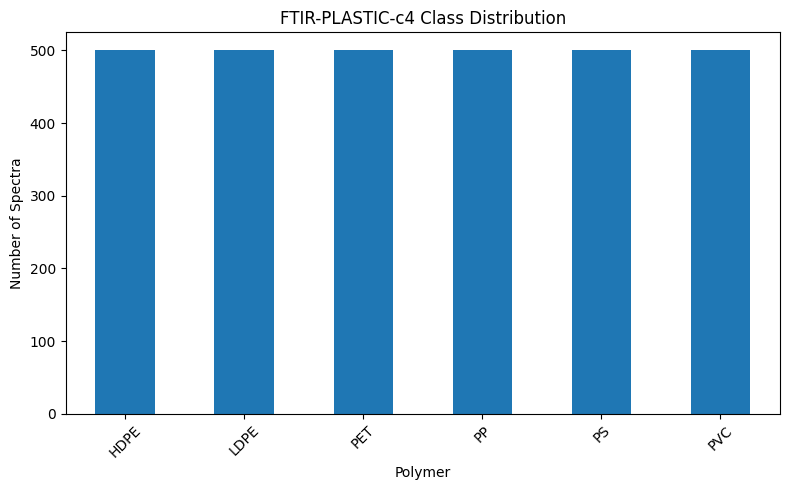

Saved to: ../results/classification/eda_spectra\class_distribution.png


In [5]:
class_counts = pd.Series(labels).value_counts().sort_index()
print(class_counts)
plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar")
plt.title("FTIR-PLASTIC-c4 Class Distribution")
plt.xlabel("Polymer")
plt.ylabel("Number of Spectra")
plt.xticks(rotation=45)
plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, "class_distribution.png")
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved to: {save_path}")

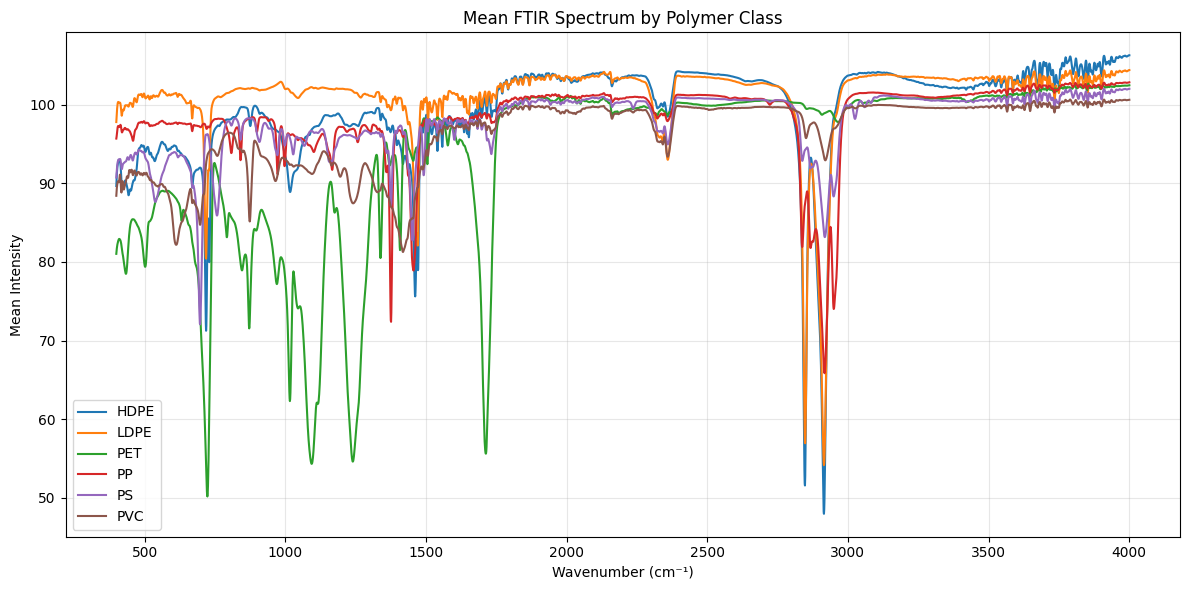

Saved to: ../results/classification/eda_spectra\mean_spectra_overlay.png


In [6]:
classes = sorted(np.unique(labels))
plt.figure(figsize=(12, 6))
for polymer in classes:
    class_spectra = spectra[labels == polymer]
    mean_spectrum = class_spectra.mean(axis=0)
    plt.plot(
        wavenumbers,
        mean_spectrum,
        label=polymer
    )
plt.title("Mean FTIR Spectrum by Polymer Class")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Mean Intensity")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, "mean_spectra_overlay.png")
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved to: {save_path}")

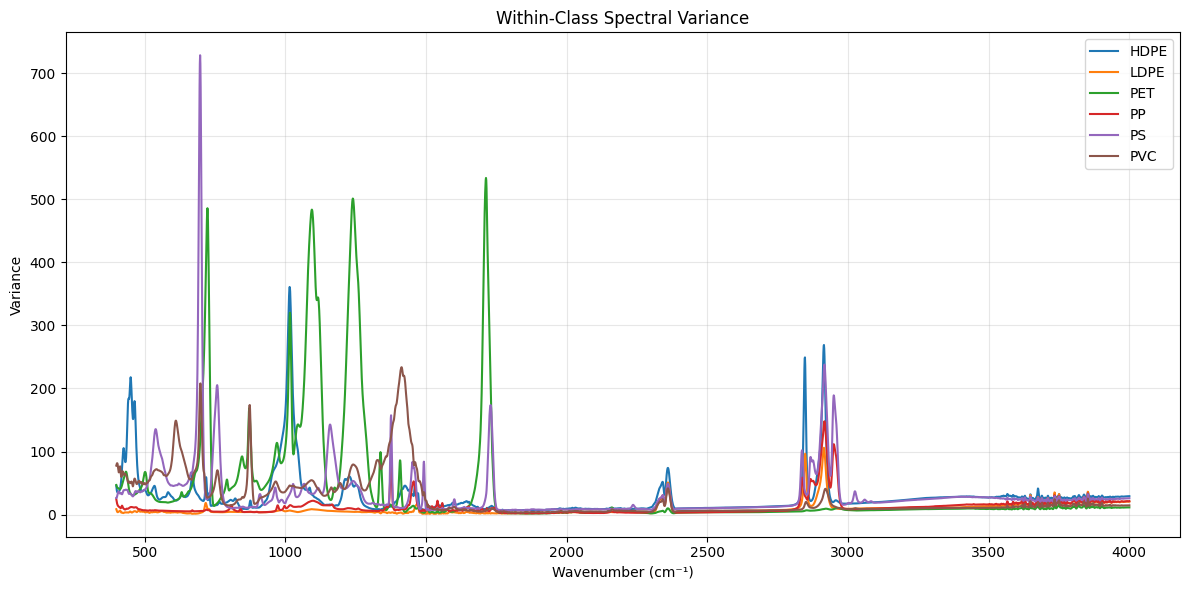

Saved to: ../results/classification/eda_spectra\within_class_variance.png


In [7]:
plt.figure(figsize=(12, 6))
for polymer in classes:
    class_spectra = spectra[labels == polymer]
    variance_spectrum = class_spectra.var(axis=0)

    plt.plot(
        wavenumbers,
        variance_spectrum,
        label=polymer
    )

plt.title("Within-Class Spectral Variance")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Variance")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

save_path = os.path.join(RESULTS_DIR, "within_class_variance.png")
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved to: {save_path}")

In [8]:
target_min = 280
target_max = 320

available = (wavenumbers >= target_min) & (wavenumbers <= target_max)

print(f"Requested region: {target_min}–{target_max} cm⁻¹")
print(f"Available points in this region: {available.sum()}")

if available.sum() == 0:
    print(
        "The 280–320 cm⁻¹ region is outside the FTIR-PLASTIC-c4 "
        "wavenumber range."
    )
else:
    print(
        f"Available range: {wavenumbers[available].min()}–"
        f"{wavenumbers[available].max()} cm⁻¹"
    )

Requested region: 280–320 cm⁻¹
Available points in this region: 0
The 280–320 cm⁻¹ region is outside the FTIR-PLASTIC-c4 wavenumber range.


## 280–320 cm⁻¹ Region Check
The FTIR-PLASTIC-c4 dataset covers approximately 399.19–4000.60 cm⁻¹.
Therefore, the 280–320 cm⁻¹ region specified in the project guide is not available in this secondary C4 dataset. No water-vapour interference assessment was performed for this region using C4 data.

In [1]:
from spectral import open_image
import numpy as np
import pandas as pd
SCLL_PATH = r"../data/raw/ftir_hsi/ilab/microplastic.scll"
HSI_PATH = r"../data/raw/ftir_hsi/microplastic.hdr"
lines = open(SCLL_PATH, encoding="latin1", errors="ignore").read().splitlines()
items = []
cur = {}

for line in lines:
    line = line.strip()

    if line == "#iscEndOfItem 0":
        if cur.get("label") in ["PE", "PP", "PS", "PMMA", "PAN"]:
            items.append(cur.copy())
        cur = {}

    elif line.startswith("#iscCaption "):
        cur["label"] = line.split(" ", 1)[1].strip()

    elif line.startswith("#iscPosX "):
        cur["x"] = int(line.split()[1])

    elif line.startswith("#iscPosY "):
        cur["y"] = int(line.split()[1])

    elif line.startswith("#iscClassNr "):
        cur["class_nr"] = int(line.split()[1])

labels_df = pd.DataFrame(items)

print("Labelled polymer pixels:", len(labels_df))
print("\nClass distribution:")
print(labels_df["label"].value_counts().sort_index())
print("\nFirst 5:")
print(labels_df.head())

Labelled polymer pixels: 150

Class distribution:
label
PAN     30
PE      30
PMMA    30
PP      30
PS      30
Name: count, dtype: int64

First 5:
     x    y  class_nr label
0  118  220         3    PE
1  117  220         3    PE
2  116  220         3    PE
3  116  219         3    PE
4  117  219         3    PE


In [2]:
img = open_image(HSI_PATH)
hsi = img.load()

print("HSI shape:", hsi.shape)

spectra = []

for _, row in labels_df.iterrows():
    x = int(row["x"])
    y = int(row["y"])
    
    spectrum = hsi[y, x, :]
    spectra.append(spectrum)

spectra = np.asarray(spectra)

print("Extracted spectra shape:", spectra.shape)
print("Expected shape: (150, 609)")
print("NaN values:", np.isnan(spectra).sum())

HSI shape: (276, 295, 609)
Extracted spectra shape: (150, 1, 1, 609)
Expected shape: (150, 609)
NaN values: 0


In [3]:
spectra = np.squeeze(spectra)
print("Corrected spectra shape:", spectra.shape)
print("Expected shape: (150, 609)")
print("NaN values:", np.isnan(spectra).sum())

Corrected spectra shape: (150, 609)
Expected shape: (150, 609)
NaN values: 0


In [4]:
wavelengths = np.asarray(img.metadata["wavelength"], dtype=float)
print("Number of wavelengths:", len(wavelengths))
print("First 10:", wavelengths[:10])
print("Last 10:", wavelengths[-10:])
print("Min:", wavelengths.min())
print("Max:", wavelengths.max())

Number of wavelengths: 609
First 10: [3594.5 3590.7 3586.8 3583.  3579.1 3575.3 3571.4 3567.5 3563.7 3559.8]
Last 10: [1284.3 1280.5 1276.6 1272.7 1268.9 1265.  1261.2 1257.3 1253.5 1249.6]
Min: 1249.6
Max: 3594.5


In [5]:
print("Band 280:", wavelengths[280], "cm^-1")
print("Band 320:", wavelengths[320], "cm^-1")
print("Range:", wavelengths[280:321].min(), "to", wavelengths[280:321].max(), "cm^-1")

Band 280: 2514.6 cm^-1
Band 320: 2360.4 cm^-1
Range: 2360.4 to 2514.6 cm^-1


In [6]:
class_means = {}
for label in labels_df["label"].unique():
    class_means[label] = spectra[labels_df["label"].values == label].mean(axis=0)
target_bands = np.arange(280, 321)
print("Target bands:", target_bands[0], "to", target_bands[-1])
print("Wavenumber:", wavelengths[target_bands[-1]], "to", wavelengths[target_bands[0]], "cm^-1")
print("Classes:", list(class_means.keys()))

Target bands: 280 to 320
Wavenumber: 2360.4 to 2514.6 cm^-1
Classes: ['PE', 'PP', 'PMMA', 'PAN', 'PS']


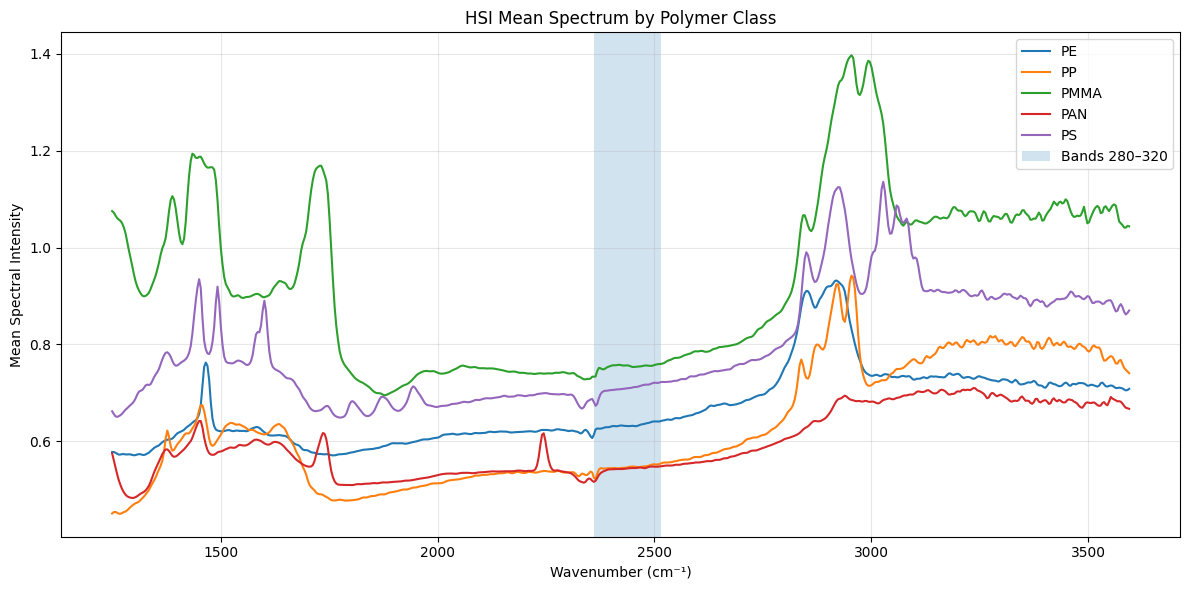

Saved: ../results/classification/eda_spectra/hsi_mean_spectra_overlay.png


In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
for label, mean_spectrum in class_means.items():
    plt.plot(wavelengths, mean_spectrum, label=label)

# Highlight bands 280–320
plt.axvspan(
    wavelengths[320],
    wavelengths[280],
    alpha=0.2,
    label="Bands 280–320"
)

plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Mean Spectral Intensity")
plt.title("HSI Mean Spectrum by Polymer Class")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

output_path = "../results/classification/eda_spectra/hsi_mean_spectra_overlay.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", output_path)

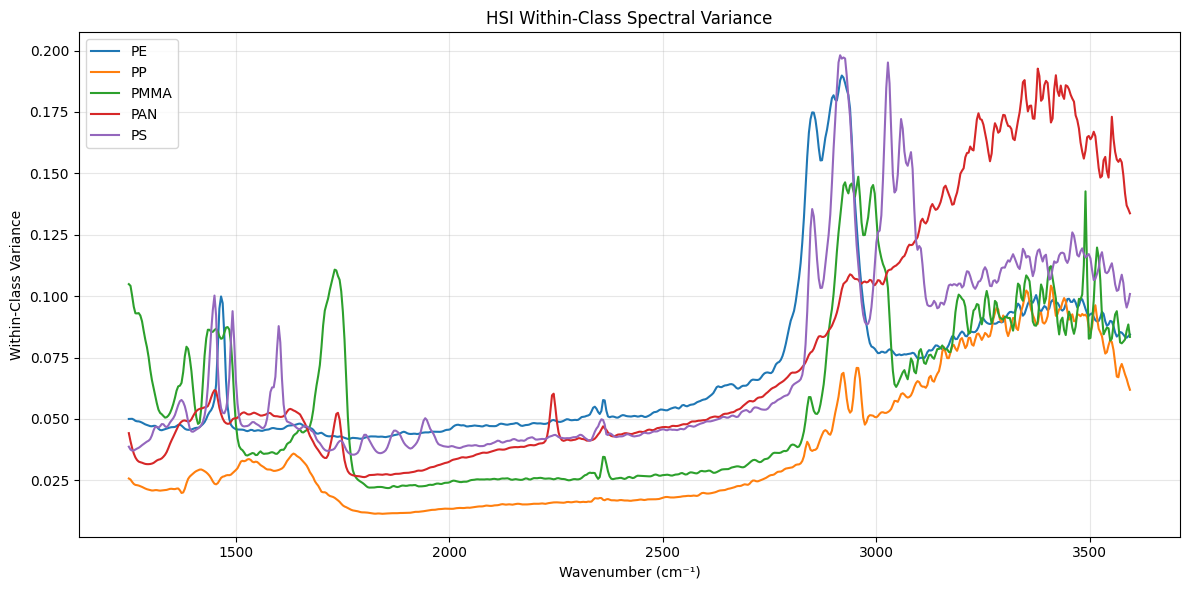

Saved: ../results/classification/eda_spectra/hsi_within_class_variance.png


In [8]:
class_variances = {}
for label in class_means.keys():
    class_spectra = spectra[labels_df["label"].values == label]
    class_variances[label] = np.var(class_spectra, axis=0)
plt.figure(figsize=(12, 6))
for label, variance in class_variances.items():
    plt.plot(wavelengths, variance, label=label)
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Within-Class Variance")
plt.title("HSI Within-Class Spectral Variance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
output_path = "../results/classification/eda_spectra/hsi_within_class_variance.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output_path)

In [9]:
target_spectra = spectra[:, 280:321]
print("Target region shape:", target_spectra.shape)
print("Wavenumber range:",
      wavelengths[320], "to", wavelengths[280], "cm^-1")
print("\nMean intensity:")
print("  Min:", target_spectra.mean(axis=0).min())
print("  Max:", target_spectra.mean(axis=0).max())
print("\nWithin-class variance:")
target_variance = np.array([
    class_variances[label][280:321].mean()
    for label in class_variances
])
for label, var in zip(class_variances.keys(), target_variance):
    print(f"  {label}: {var:.6f}")

Target region shape: (150, 41)
Wavenumber range: 2360.4 to 2514.6 cm^-1

Mean intensity:
  Min: 0.6136861
  Max: 0.6451988

Within-class variance:
  PE: 0.052044
  PP: 0.017149
  PMMA: 0.027059
  PAN: 0.044896
  PS: 0.044210


In [6]:
import pandas as pd
SCLL_PATH = r"../data/raw/ftir_hsi/ilab/microplastic.scll"
lines = open(SCLL_PATH, encoding="latin1", errors="ignore").read().splitlines()
items = []
cur = {}
for line in lines:
    line = line.strip()

    if line == "#iscEndOfItem 0":
        if cur.get("label") in ["PE", "PP", "PS", "PMMA", "PAN"]:
            items.append(cur.copy())
        cur = {}

    elif line.startswith("#iscCaption "):
        cur["label"] = line.split(" ", 1)[1].strip()

    elif line.startswith("#iscPosX "):
        cur["x"] = int(line.split()[1])

    elif line.startswith("#iscPosY "):
        cur["y"] = int(line.split()[1])

    elif line.startswith("#iscClassNr "):
        cur["class_nr"] = int(line.split()[1])

labels_df = pd.DataFrame(items)

print("Labelled polymer pixels:", len(labels_df))
print("\nClass distribution:")
print(labels_df["label"].value_counts().sort_index())

Labelled polymer pixels: 150

Class distribution:
label
PAN     30
PE      30
PMMA    30
PP      30
PS      30
Name: count, dtype: int64


In [7]:
from spectral import open_image
import numpy as np
HSI_PATH = r"../data/raw/ftir_hsi/microplastic.hdr"
img = open_image(HSI_PATH)
hsi = img.load()
spectra = []
for _, row in labels_df.iterrows():
    x = int(row["x"])
    y = int(row["y"])
    spectrum = hsi[y, x, :]
    spectra.append(spectrum)

spectra = np.squeeze(np.asarray(spectra))

print("HSI shape:", hsi.shape)
print("Extracted spectra shape:", spectra.shape)
print("NaN values:", np.isnan(spectra).sum())

HSI shape: (276, 295, 609)
Extracted spectra shape: (150, 609)
NaN values: 0


In [8]:
import sys
sys.path.insert(0, "..")
from src.preprocessing.spectral_preprocess import preprocess_spectra
processed_spectra = preprocess_spectra(spectra)
print("Raw shape:", spectra.shape)
print("Processed shape:", processed_spectra.shape)
row_means = processed_spectra.mean(axis=1)
row_stds = processed_spectra.std(axis=1)
print("Maximum absolute spectrum mean:", np.abs(row_means).max())
print("Minimum spectrum std:", row_stds.min())
print("Maximum spectrum std:", row_stds.max())

Raw shape: (150, 609)
Processed shape: (150, 609)
Maximum absolute spectrum mean: 4.697903e-07
Minimum spectrum std: 0.9999999
Maximum spectrum std: 1.0000001


In [9]:
from src.preprocessing.spectral_preprocess import (
    savitzky_golay_smooth,
    zero_bands
)

smoothed = savitzky_golay_smooth(
    spectra,
    window_length=11,
    polyorder=2
)

zeroed = zero_bands(smoothed, 280, 320)

print("Zeroed shape:", zeroed.shape)
print("Bands 280-320 minimum:", zeroed[:, 280:321].min())
print("Bands 280-320 maximum:", zeroed[:, 280:321].max())

Zeroed shape: (150, 609)
Bands 280-320 minimum: 0.0
Bands 280-320 maximum: 0.0


In [10]:
print("Number of HSI images/samples:", 1)
print("Current labelled spectra:", len(spectra))
print("Unique sample IDs available:", 1)

Number of HSI images/samples: 1
Current labelled spectra: 150
Unique sample IDs available: 1


In [11]:
from src.preprocessing.spectral_preprocess import sample_level_split
sample_ids = np.array(["microplastic_hsi"] * len(spectra))
try:
    sample_level_split(
        processed_spectra,
        labels_df["label"].values,
        sample_ids
    )
except ValueError as e:
    print("Split correctly blocked:")
    print(e)

Split correctly blocked:
At least 2 unique samples/images are required for a sample-level train/test split.
